# OpenCV第3回：画像補正の基礎

画像処理の手法のなかでも数学的演算を活用して画像補正を行う基本的な方法について学ぶ。ここでは以下の３つに触れていく。  
・加算や乗算を用いた算術演算  
→全画素に一定値を足したり掛け合わせることで、明度やコントラストを焼成できる。  
・閾値処理とマスキング  
→ある値を境に白黒２値に分ける。これは、「対象領域を取り出す」処理の基礎となる。  
・OR、AND、XORなどのビット演算  
→マスクと組み合わせて画像の恥部だけを切り抜いたり、合成したりする。  

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve

from IPython.display import Image
%matplotlib inline

## 画像のダウンロード

In [2]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    urlretrieve(url, save_path)
    
    try:
        with ZipFile(save_path) as z:
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [3]:
URL = r"https://www.dropbox.com/s/0oe92zziik5mwhf/opencv_bootcamp_assets_NB4.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), f"opencv_bootcamp_assets_NB4.zip")

if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path) 

## 画像データの確認

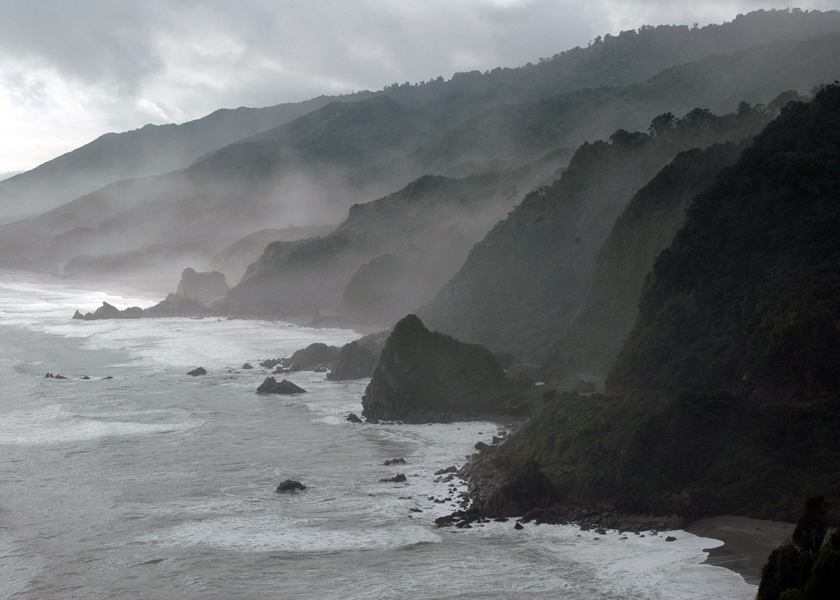

In [4]:
# カラー画像の読み込み
img_bgr = cv2.imread("New_Zealand_Coast.jpg", cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

Image(filename="New_Zealand_Coast.jpg")

## 加算：明るさの調整

画像の単純な加算処理により、各画素のピクセル値を同じ量だけ増減させることが可能となり、画像の明度を調整することが出来る。  

`cv2.add(img, matrix)`：足し算(img + matrix)。255が頭打ちになるように計算される。  
`cv2.subtract(img, matrix)`：引き算(img - matrix)。0が  
・img：元画像  
・matrix：入力配列。  
※imgとmatrixは型が揃っている必要がある。  

img + mのような計算も可能だが、ピクセル値の範囲(0~255)を超えるような計算だと出力結果が壊れる。(ロールオーバー：255を超えた分はまた0からその分だけ数えた値を取る)

In [5]:
print(f"高さ, 幅, チャネル：{img_rgb.shape}")

高さ, 幅, チャネル：(600, 840, 3)


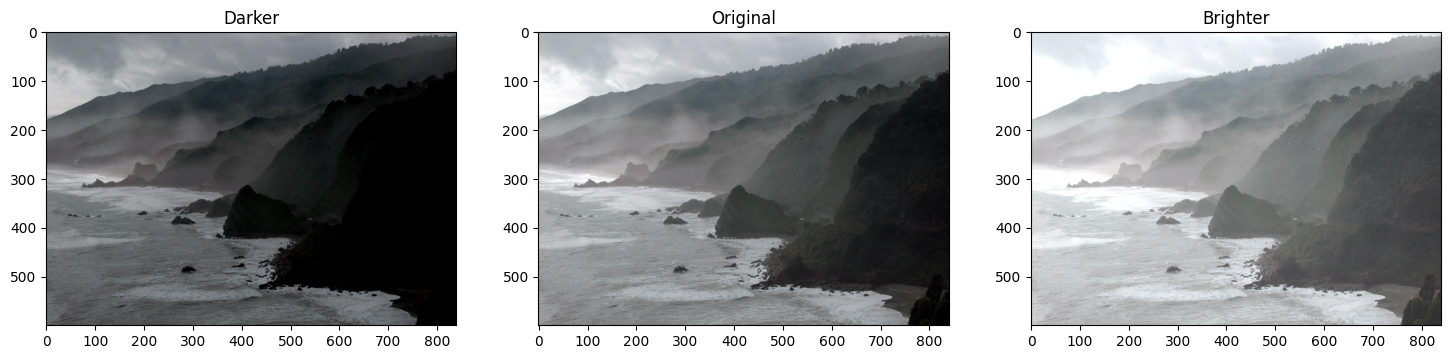

In [6]:
# np.ones()：指定した形で全要素が1の配列を生成する  
# 1のみの(600, 840, 3)の3次元配列を生成  
# dtype="uint8":元画像の画素値と同じデータ型を指定。指定しないとfloat64になり、演算でエラーが出る。
matrix = np.ones(img_rgb.shape, dtype="uint8") *50

img_rgb_brighter = cv2.add(img_rgb, matrix)
img_rgb_darker = cv2.subtract(img_rgb, matrix)

plt.figure(figsize=[18, 5])
plt.subplot(131); plt.imshow(img_rgb_darker);  plt.title("Darker");
plt.subplot(132); plt.imshow(img_rgb);         plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_brighter);plt.title("Brighter");

## 乗算：コントラストの調整

乗算は、画像のコントラスト調整に用いる。  
コントラストとは、画像のピクセル値間の差のことであり、ピクセル値に定数を掛けることで、その差を大きくしたり、小さくしたりすることが出来る。  

`cv2.multiply(img, matrix)`  
・img：元画像  
・matrix：入力配列。  
※imgとmatrixは方が揃っている必要がある。

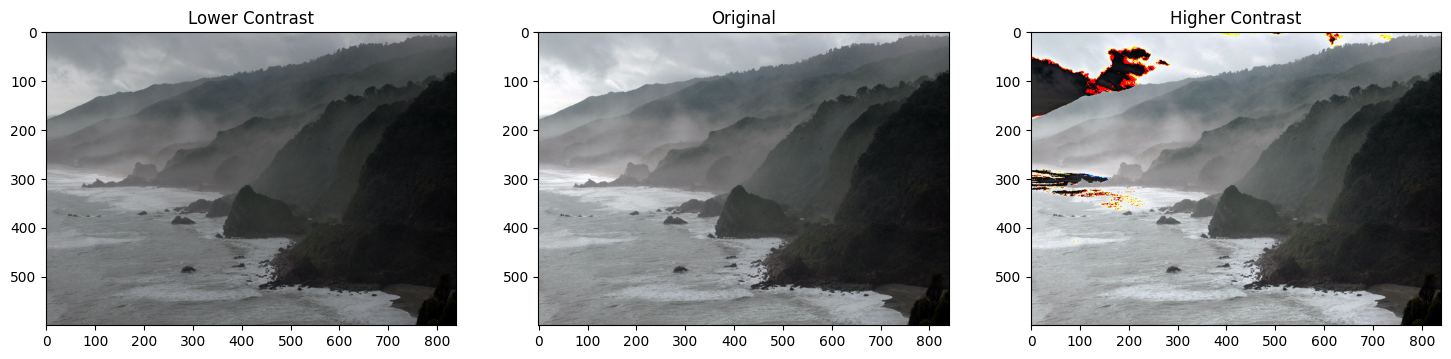

In [7]:
# 1のみの(600, 840, 3)の3次元配列を生成し、0.8(/1.2)を掛け合わせる  
matrix1 = np.ones(img_rgb.shape) * 0.8
matrix2 = np.ones(img_rgb.shape) * 1.2

img_rgb_darker = np.uint8(cv2.multiply(np.float64(img_rgb), matrix1))
img_rgb_brighter = np.uint8(cv2.multiply(np.float64(img_rgb), matrix2))
# np.float64():matrix1/2がfloat64型なので、乗算のためにimg_rgbの型を合わせる
# np.uint8()：最終的に画像として出力させるにはuint8型でなければならない  

plt.figure(figsize=[18, 5])
plt.subplot(131); plt.imshow(img_rgb_darker);    plt.title("Lower Contrast");
plt.subplot(132); plt.imshow(img_rgb);           plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_brighter); plt.title("Higher Contrast");


Higher Contrastの画像がおかしな理由  
np.float64は255以上の値も取ることが出来るので、1.2倍で計算した時に255を超える値が出てきて、それらはロールオーバーを起こした。  

これを解決するのが`np.clip()`！  
`np.clip(画素値データ, 最小値, 最大値)`  
→計算後の画像データの指定した範囲外の値を境界値に丸める

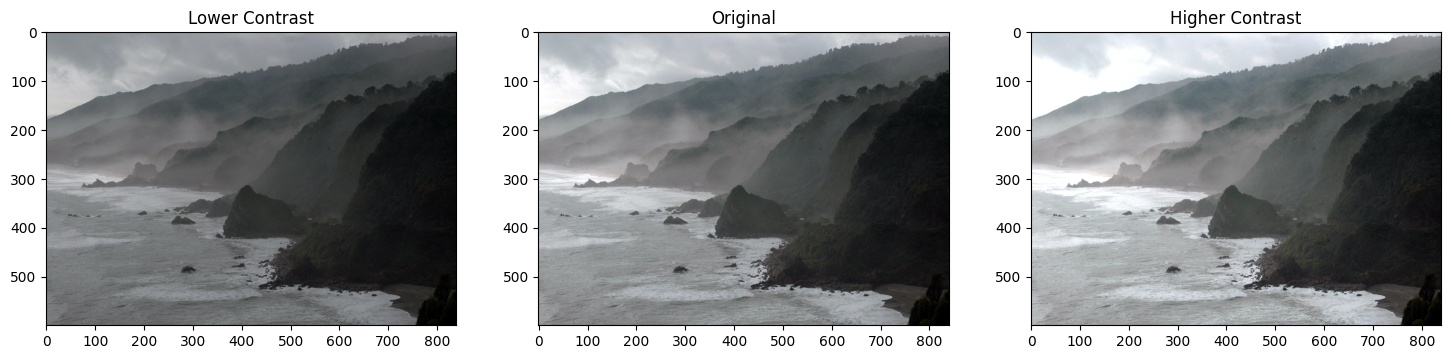

In [8]:
matrix1 = np.ones(img_rgb.shape) * 0.8
matrix2 = np.ones(img_rgb.shape) * 1.2

img_rgb_lower  = np.uint8(cv2.multiply(np.float64(img_rgb), matrix1))
img_rgb_higher = np.uint8(np.clip(cv2.multiply(np.float64(img_rgb), matrix2), 0, 255))

plt.figure(figsize=[18,5])
plt.subplot(131); plt.imshow(img_rgb_lower); plt.title("Lower Contrast");
plt.subplot(132); plt.imshow(img_rgb);       plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_higher);plt.title("Higher Contrast");

## 閾値処理

二値画像は、画像処理において多くの用途をもつ。最も一般的な使い道の一つが`マスクの作成`である。マスクを使うことで、画像の特定の部分だけを処理して、それ以外の部分は保持することが出来る。  
閾値処理は、グレースケール画像から二値画像を作成するために使われる。同じ元画像でも異なる閾値を指定すれば異なる二値画像を作成できる。  

これらは、物体検出、顔認識などのタスクで、背景と前景の区別に使用されたり、ノイズ除去やエッジ検出などの前処理にも使われる。

`retval, dst = cv2.threshold(src, thresh, maxval, type)`  
・src：入力画像  
・thresh：閾値  
・maxval：THRESH_BINARYおよびTHRESH_BINARY_INVの処理で使用する最大値  
・type：閾値処理の種類  
<typeの種類>  
| タイプ | 閾値より大きい時 | 閾値より小さい時 |  
| --- | --- | --- |  
| cv2.THRESH_BINARY | 最大値(maxval) | 0 | 
| cv2.THRESH_BINARY_INV | 0 | 最大値(maxval) | 
| cv2.THRESH_TRUNC | 閾値(thresh) | 入力のまま | 
| cv2.THRESH_TOZERO | 入力のまま | 0 | 
| cv2.THRESH_TOZERO_INV | 0 | 入力のまま |  

戻り値は実際に使用した閾値(retval)と二値化された画像(dst)の2つが返ってくる。retvalはthreshで指定した値が返ってくるだけなので、慣習的にアンダースコアで捨てることが多い。  

(572, 800)


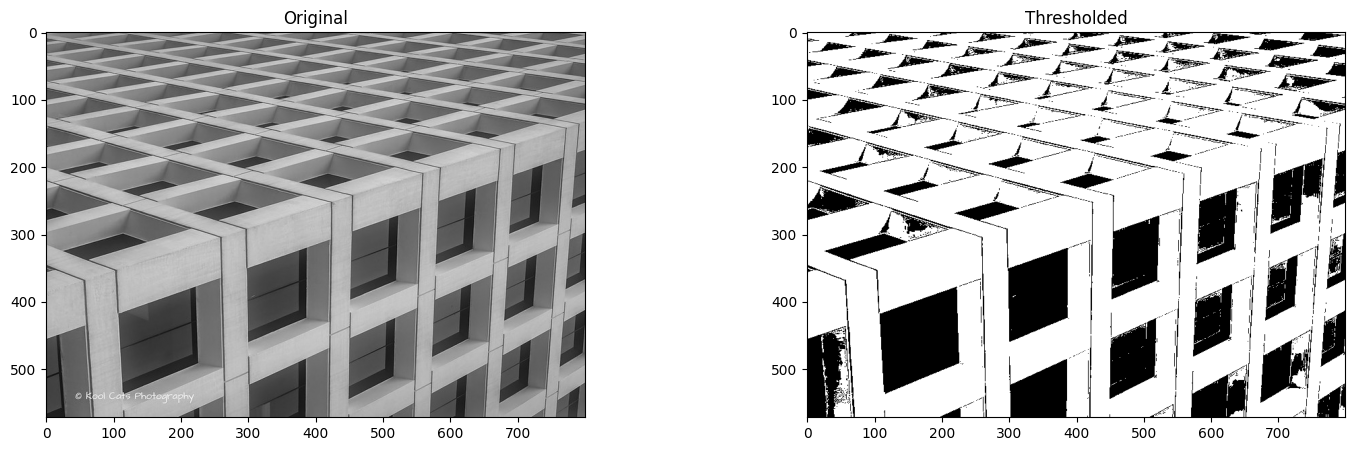

In [9]:
img_read = cv2.imread("building-windows.jpg", cv2.IMREAD_GRAYSCALE)
retval, img_thresh = cv2.threshold(img_read, 100, 255, cv2.THRESH_BINARY)

plt.figure(figsize=[18, 5])

plt.subplot(121);plt.imshow(img_read, cmap="gray");  plt.title("Original")
plt.subplot(122);plt.imshow(img_thresh, cmap="gray");plt.title("Thresholded")

print(img_thresh.shape)

上記では、閾値を100として、閾値処理タイプをTHRESH_BINARYとしているので、100以上の画素値は255、それ以外は0という処理を画像に施している。

`cv2.adaptiveThreshold(src, maxValue, adaptiveMethod, thresholdType, blockSize, C)`  
・src：入力画像  
・maxValue：閾値以上の値がとる値。  
・adaptiveMethod：閾値の計算手法。  
| 種類 | 内容 | 
| --- | --- | 
| cv2.ADAPTIVE_THRESH_MEAN_C | 近傍画素値の平均 | 
| cv2.ADAPTIVE_THRESH_GAUSSIAN_C | ガウシアンの重み付き平均値 | 

・threshholdType：閾値処理の種類。`cv2.THRESH_BINARY`もしくは`cv2.THRESH_BINARY_INV`のいずれか。  
・blockSize：画素の閾値を計算するために使用する近傍領域の大きさ。3,5,7など奇数で設定する。  
・C：近傍の平均値から差し引く定数。  

Cは0の時、無地の領域で画素値と周囲の平均がほぼ等しいため、各画素は「平均より上か下か」で判定されます。無地の領域でも画素間にわずかな差が存在し、その中で平均が算出されるため、必ず、約半分が閾値以上(白)、もう半分が閾値以下(黒)に振り分けられてしまい、結果的に少しのノイズで背景が砂嵐のようになってしまいます。
Cは大きくするほどノイズが消えていきますが、代わりに薄い文字などは薄まりやすくなり、ノイズ除去と文字の保持はトレードオフの関係にあるので、実務では何パターンか検証しながら値を決めることをお薦めします。  

以下では、先ほどのcv2.threshhold()と比較した結果を確認しています。

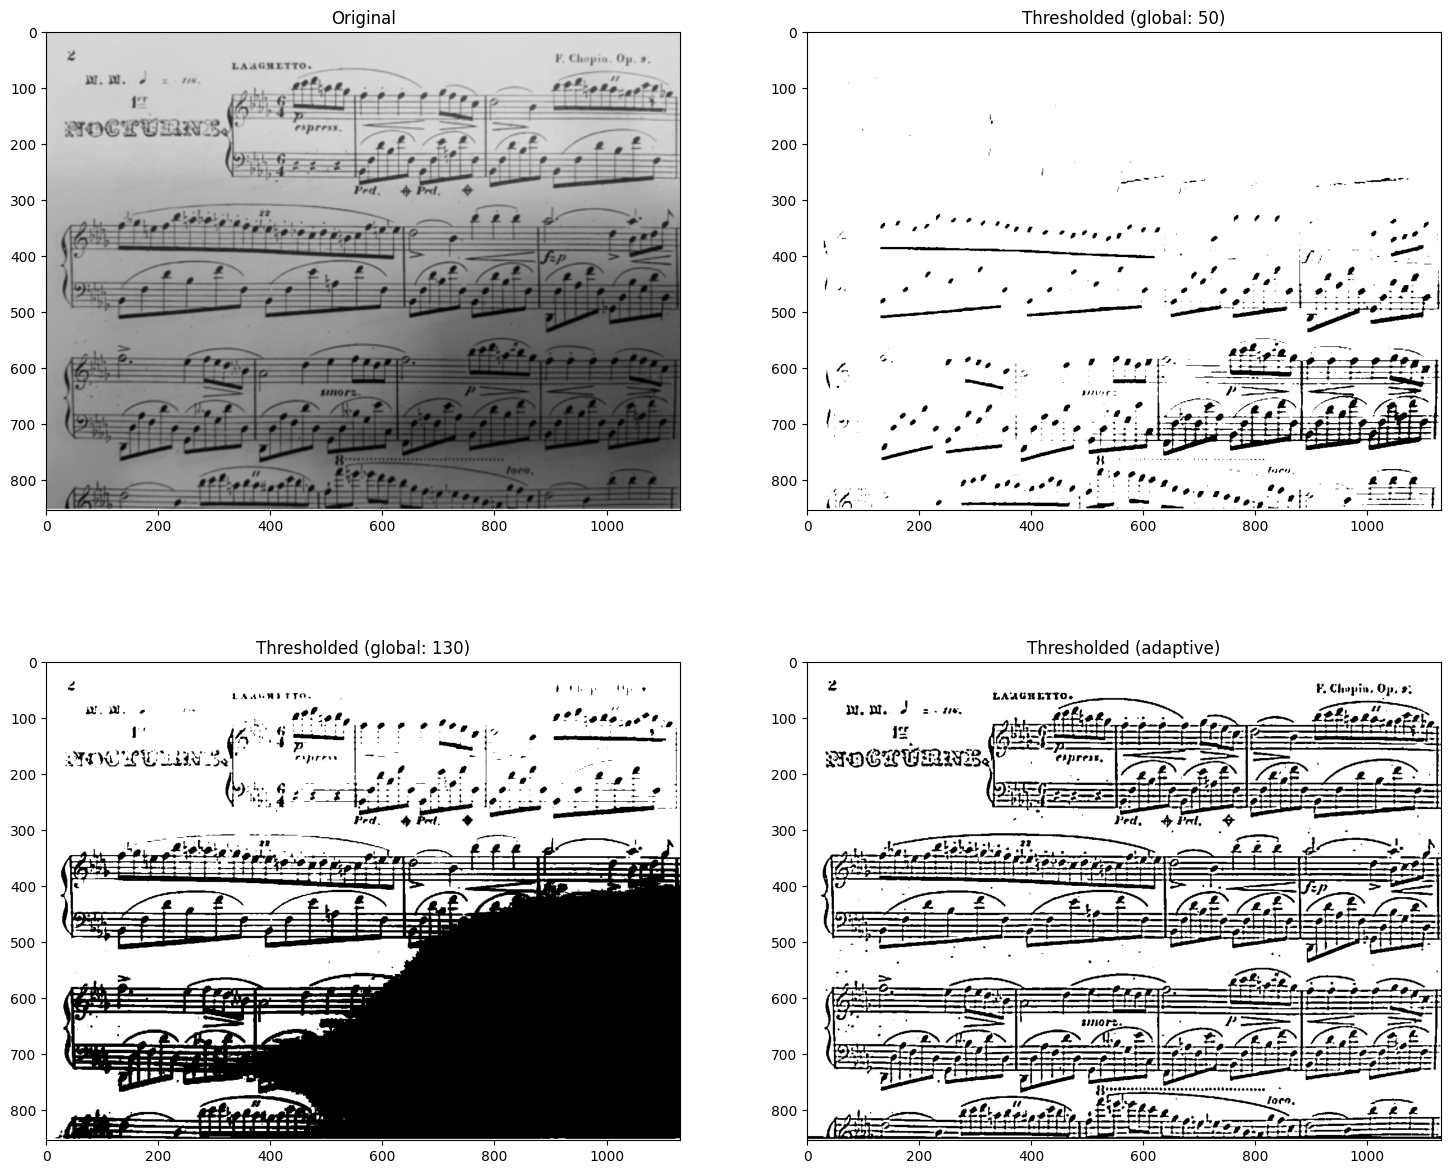

In [10]:
img_read = cv2.imread("Piano_Sheet_Music.png", cv2.IMREAD_GRAYSCALE)

retval, img_thresh_gbl_1 = cv2.threshold(img_read, 50, 255, cv2.THRESH_BINARY)

retval, img_thresh_gbl_2 = cv2.threshold(img_read, 130, 255, cv2.THRESH_BINARY)

img_thresh_adp = cv2.adaptiveThreshold(img_read, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 7)

plt.figure(figsize=[18,15])
plt.subplot(221); plt.imshow(img_read,        cmap="gray");  plt.title("Original");
plt.subplot(222); plt.imshow(img_thresh_gbl_1,cmap="gray");  plt.title("Thresholded (global: 50)");
plt.subplot(223); plt.imshow(img_thresh_gbl_2,cmap="gray");  plt.title("Thresholded (global: 130)");
plt.subplot(224); plt.imshow(img_thresh_adp,  cmap="gray");  plt.title("Thresholded (adaptive)");

上記のような照明が不均一で影が入っている画像を閾値処理する際に、cv2.threshhold()を使用すると、画像全体で1つの閾値を適用するため、明るい領域と暗い領域を同時に正しく処理できないことが分かります。  
しきい値を50に設定した場合、影の濃い右下の音符はかろうじて残るものの、左上の明るい領域にある音符やタイトルはほとんど白く飛んでしまいます。逆にしきい値を130に上げると、左上の楽譜は読めるようになりますが、今度は影のかかった右下が広範囲にわたって黒く塗り潰され、情報が完全に失われています。どちらの値を選んでも、画像の半分は破綻してしまうわけです。  

一方でcv2.adaptiveThreshhold()を使用すると、画像全体にわたって音符・五線・タイトルのいずれもが均等に抽出できています。各画素のしきい値を周囲の明るさから個別に計算しているため、影の有無に関わらず「周囲と比べて暗い部分」を文字として拾えるからです。背景に細かなノイズは見られるものの、楽譜の情報そのものはほぼ失われていません。

2つの関数は以下の条件で使い分けができる。  
`cv2.threshhold()`  
・照明が均一な画像  
・撮影条件が固定されいる場合(検査装置、固定カメラなど)  
・二値化以外の用途で使用したい場合(cv2.THRESH_TRUNC、cv2.TOZERO)  

`cv2.adaptiveThreshhold()`  
・照明にむらがある画像  
・影が入った画像  
・スキャン画像、手書き文字の抽出  
・撮影条件が毎回変わる場合  

## ビット演算

マスクを使った切り抜き・合成処理  
`cv2.bitwise_and(src1, src2, mask)`  
src1:1つ目の入力配列 or スカラー値  
src2:2つ目の入力配列 or スカラー値  
mask(任意):演算マスク。出力配列のうち変更される要素を指定。

(200, 499)


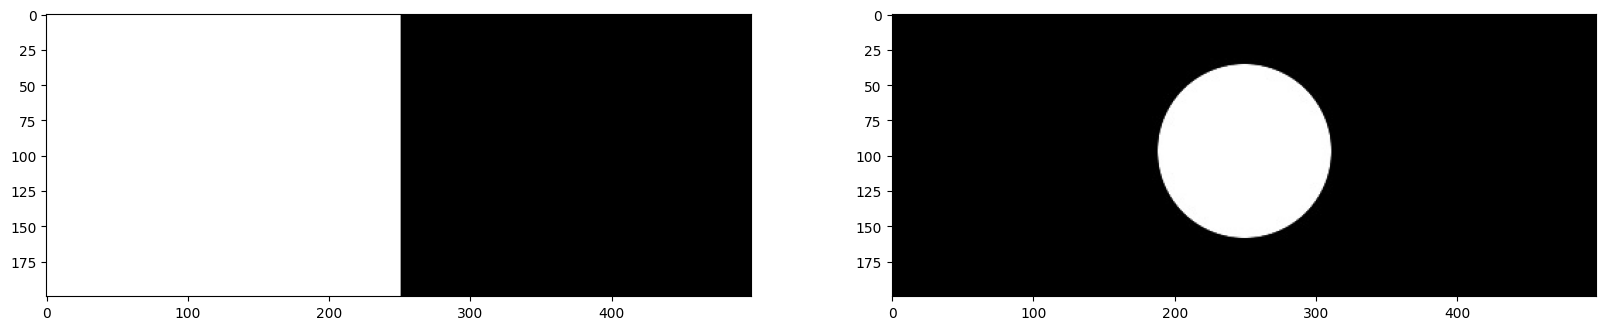

In [11]:
img_rec = cv2.imread("rectangle.jpg", cv2.IMREAD_GRAYSCALE)
img_cir = cv2.imread("circle.jpg", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=[20, 5])
plt.subplot(121);plt.imshow(img_rec, cmap="gray")
plt.subplot(122);plt.imshow(img_cir, cmap="gray")
print(img_rec.shape)

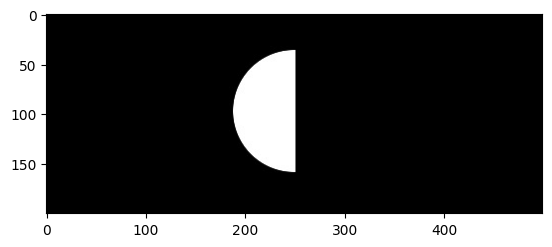

In [12]:
# ビットAND演算子
result = cv2.bitwise_and(img_rec, img_cir, mask=None)
plt.imshow(result, cmap="gray")

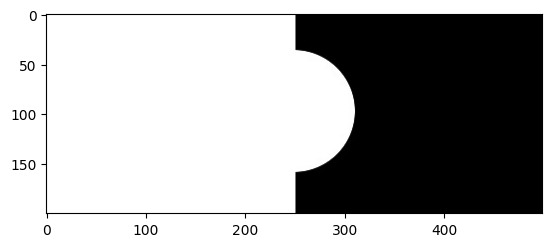

In [13]:
# ビットOR演算子
result = cv2.bitwise_or(img_rec, img_cir, mask=None)
plt.imshow(result, cmap="gray")

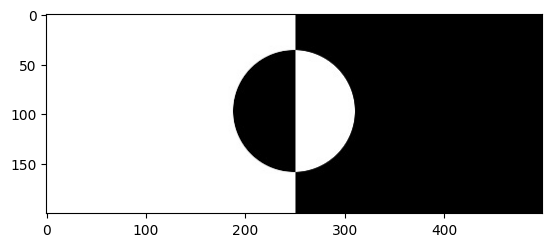

In [14]:
# ビットXOR演算
result = cv2.bitwise_xor(img_rec, img_cir, mask=None)
plt.imshow(result, cmap="gray")

## ロゴの合成

ここでは、コカ・コーラのロゴの白い文字部分を背景画像で埋める方法を紹介する。  

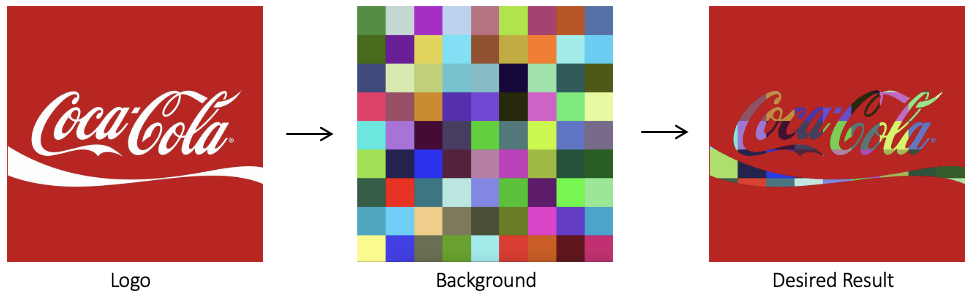

In [4]:
Image(filename="Logo_Manipulation.png")

(700, 700, 3)


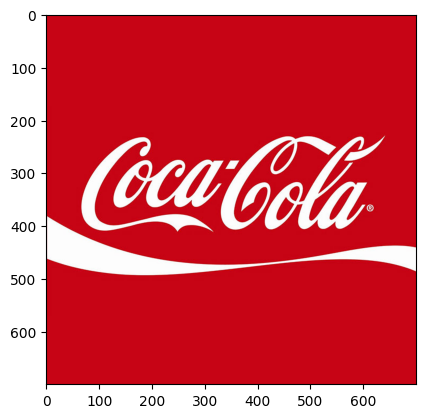

In [5]:
# 前景画像の読み込み
img_bgr = cv2.imread("coca-cola-logo.png")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

print(img_rgb.shape)

logo_h = img_rgb.shape[0]
logo_w = img_rgb.shape[1]

(1800, 1800, 3)


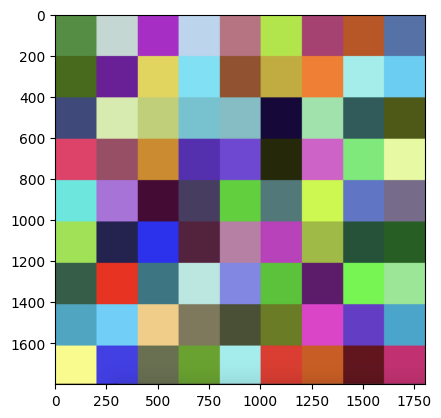

In [7]:
# 背景画像の読み込み
img_background_bgr = cv2.imread("checkerboard_color.png")
img_background_rgb = cv2.cvtColor(img_background_bgr, cv2.COLOR_BGR2RGB)
print(img_background_rgb.shape)

plt.imshow(img_background_rgb)

(700, 700, 3)


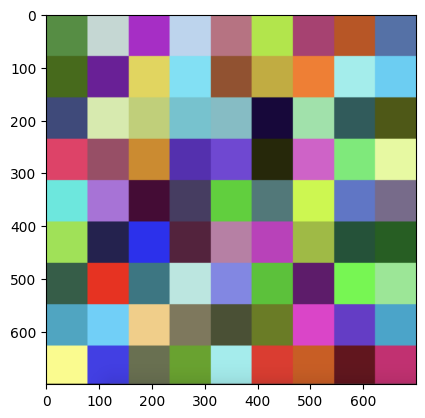

In [18]:
# 背景画像の読み込み
img_background_bgr = cv2.imread("checkerboard_color.png")
img_background_rgb = cv2.cvtColor(img_background_bgr, cv2.COLOR_BGR2RGB)

# アスペクト比の算出
aspect_ratio = logo_w / img_background_rgb.shape[1]
dim = (logo_w, int(img_background_rgb.shape[0] * aspect_ratio))

# 前景画像と同じサイズにリサイズ
img_background_rgb = cv2.resize(img_background_rgb, dim, interpolation=cv2.INTER_AREA)

plt.imshow(img_background_rgb)
print(img_background_rgb.shape)

### マスク作成

(700, 700)


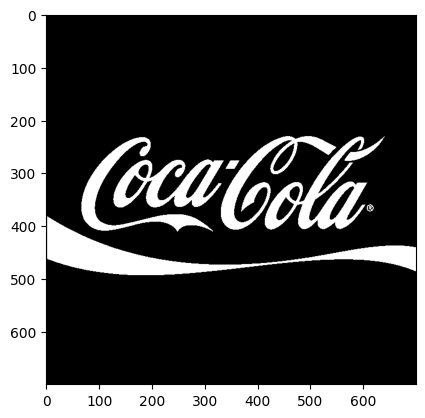

In [19]:
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# 閾値処理
retval, img_mask = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

plt.imshow(img_mask, cmap="gray")
print(img_mask.shape)

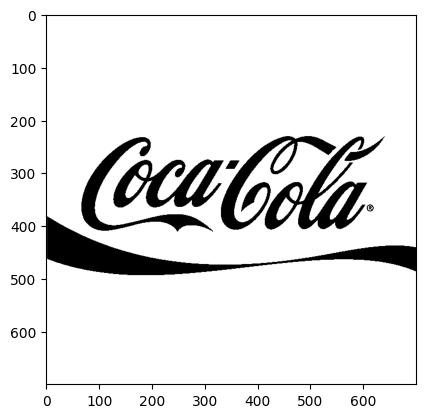

In [20]:
# マスクの反転
img_mask_inv = cv2.bitwise_not(img_mask)
plt.imshow(img_mask_inv, cmap="gray")

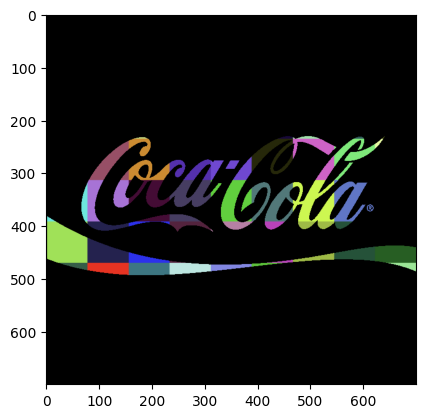

In [21]:
# 背景画像にマスクを適応
img_background = cv2.bitwise_and(img_background_rgb, img_background_rgb, mask=img_mask)
plt.imshow(img_background)

これは文字の形をしたマスクを使って背景画像を切り抜いているだけ。  
「文字の奥に風景が見えている」ように感じますが、実際には奥行きがあるわけではなく、文字の形以外をすべて0で塗り潰しただけ。

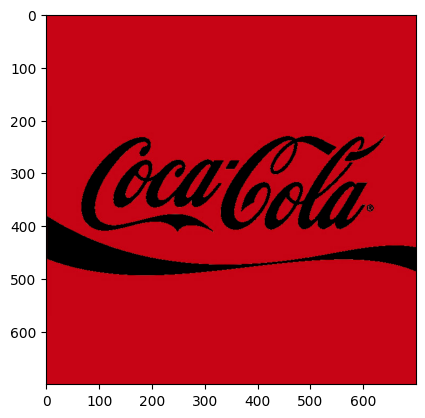

In [22]:
## 画像から前景を取り出す
# 反転マスクを使って、元画像から前景（赤色の部分）を切り出す
img_foreground = cv2.bitwise_and(img_rgb, img_rgb, mask=img_mask_inv)
plt.imshow(img_foreground)

True

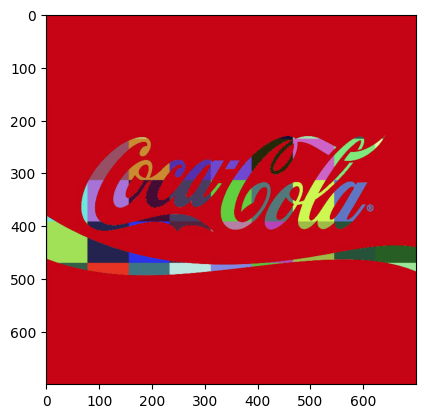

In [23]:
# 前景と背景の統合
result = cv2.add(img_background, img_foreground)
plt.imshow(result)
cv2.imwrite("logo_final.png", result[:, :, ::-1])